# Lizard Image Classification Pipeline - Kaggle Final Training

Deze Kaggle-versie is compact gehouden, maar bevat wel Optuna, final training, final evaluation met curves/confusion matrix/inference strategy search, en het maken van `submission.csv`.

## 1. Setup

In [6]:
# Kaggle heeft de meeste packages normaal al. Zet deze aan als Optuna ontbreekt.
# %pip install -q optuna

In [7]:
from pathlib import Path
import gc
import inspect
import random
import warnings

import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import ImageFile
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision enabled.")

TensorFlow: 2.19.0
Mixed precision enabled.


In [ ]:
def show_kaggle_input_tree(max_lines=80):
    kaggle_input = Path("/kaggle/input")
    if not kaggle_input.exists():
        print("/kaggle/input does not exist in this runtime.")
        return
    shown = 0
    for path in sorted(kaggle_input.rglob("*")):
        depth = len(path.relative_to(kaggle_input).parts)
        if depth > 4:
            continue
        print("  " * depth + path.name + ("/" if path.is_dir() else ""))
        shown += 1
        if shown >= max_lines:
            print("...")
            break


def candidate_data_roots():
    candidates = [
        Path("/kaggle/input/lizard-better/AI-Lizard-Prediction-Challenge"),
        Path("/kaggle/input/lizard-better"),
        Path.cwd(),
        Path.cwd() / "AI-Lizard-Prediction-Challenge",
    ]
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend(path for path in kaggle_input.rglob("*") if path.is_dir())
    seen = set()
    for candidate in candidates:
        try:
            resolved = candidate.resolve()
        except FileNotFoundError:
            continue
        if resolved not in seen:
            seen.add(resolved)
            yield resolved


def find_data_root():
    for candidate in candidate_data_roots():
        if (candidate / "train").is_dir() and (candidate / "test").is_dir():
            return candidate
    show_kaggle_input_tree()
    raise FileNotFoundError(
        "Could not find a data root containing train/ and test/. Attach the lizard dataset to this Kaggle notebook."
    )


def find_input_file(filename, data_root):
    search_roots = [data_root, data_root.parent, Path("/kaggle/input"), Path.cwd()]
    for root in search_roots:
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            return direct.resolve()
        if root.name == "input":
            matches = sorted(root.rglob(filename))
            if matches:
                return matches[0].resolve()
    return data_root / filename


DATA_ROOT = find_data_root()
WORKING_ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else DATA_ROOT

TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
TRAIN_CSV = find_input_file("train.csv", DATA_ROOT)
TEST_CSV = find_input_file("test.csv", DATA_ROOT)

IMG_SIZE = (384, 384)
BACKBONE_NAME = "convnext_tiny"  # options: "convnext_tiny", "efficientnetv2s", "efficientnetb0", "efficientnetv2b0"
CONVNEXT_DROP_PATH_RATE = 0.10
LABEL_SMOOTHING = 0.10
ENSEMBLE_BACKBONES = ["convnext_tiny", "efficientnetv2s", "efficientnetb0"]
SKIP_ENSEMBLE_BACKBONES = ["convnext_tiny"]  # keep ConvNeXt listed, but skip it for the current active run
ACTIVE_ENSEMBLE_BACKBONES = [
    backbone_name for backbone_name in ENSEMBLE_BACKBONES
    if backbone_name not in set(SKIP_ENSEMBLE_BACKBONES)
]
ENSEMBLE_WEIGHTS = {"convnext_tiny": 0.45, "efficientnetv2s": 0.35, "efficientnetb0": 0.20}

RUN_5FOLD_OOF_CLEANLAB_EXPORT = True  # expensive one-time Cleanlab export for all train images
OOF_CLEANLAB_N_FOLDS = 5
OOF_CLEANLAB_BACKBONES = ACTIVE_ENSEMBLE_BACKBONES
ENSEMBLE_MODEL_PATHS = {}  # optional: pre-trained .keras checkpoints; empty means train all ensemble backbones
ENSEMBLE_WEIGHT_OPTUNA_TRIALS = 300
ENSEMBLE_SELECTION_MODE = "robust"  # options: "manual", "optuna", "robust"
MANUAL_ENSEMBLE_WEIGHTS = {"convnext_tiny": 0.045900, "efficientnetv2s": 0.478701, "efficientnetb0": 0.475399}
ENSEMBLE_ROBUST_SELECTION_TOLERANCE = 0.005  # choose a stabler manual blend if it is within 0.5 macro-F1 points
ENSEMBLE_ROBUST_CANDIDATE_WEIGHTS = {
    "optuna": None,
    "stable_010_045_045": {"convnext_tiny": 0.10, "efficientnetv2s": 0.45, "efficientnetb0": 0.45},
    "stable_020_040_040": {"convnext_tiny": 0.20, "efficientnetv2s": 0.40, "efficientnetb0": 0.40},
    "equal_033_033_033": {"convnext_tiny": 1/3, "efficientnetv2s": 1/3, "efficientnetb0": 1/3},
    "no_convnext_000_050_050": {"convnext_tiny": 0.00, "efficientnetv2s": 0.50, "efficientnetb0": 0.50},
}
VAL_SIZE = 0.15
BATCH_SIZE = 24
AUTOTUNE = tf.data.AUTOTUNE

RUN_OPTUNA = False
N_OPTUNA_TRIALS = 30
N_FOLDS = 5
OPTUNA_HEAD_MAX_EPOCHS = 12
OPTUNA_FINE_TUNE_MAX_EPOCHS = 12
FINAL_HEAD_EPOCHS = 40
FINAL_FORCE_FINE_TUNING = True
FINAL_FINE_TUNE_LAST_N_LAYERS = 20
FINAL_FINE_TUNE_EPOCHS = 30
FINAL_FINE_TUNE_LEARNING_RATE = 5e-5
USE_TTA = True

OPTUNA_BATCH_CHOICES = [16, 24, 32]
OPTUNA_DENSE_CHOICES = [64, 128, 256]

print("Data root:", DATA_ROOT)
print("Working root:", WORKING_ROOT)
print("Run Optuna:", RUN_OPTUNA)
print("Optuna trials:", N_OPTUNA_TRIALS)
print("Optuna folds:", N_FOLDS)
print("Active ensemble backbones:", ACTIVE_ENSEMBLE_BACKBONES)
print("Skipped ensemble backbones:", SKIP_ENSEMBLE_BACKBONES)
print("Run 5-fold OOF Cleanlab export:", RUN_5FOLD_OOF_CLEANLAB_EXPORT)

assert TRAIN_DIR.exists(), f"Missing training directory: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Missing test directory: {TEST_DIR}"
assert TRAIN_CSV.exists(), f"Missing train CSV: {TRAIN_CSV}"
assert TEST_CSV.exists(), f"Missing test CSV: {TEST_CSV}"

Data root: /kaggle/input/competitions/lizard-prediction-thomas-more
Working root: /kaggle/working
Run Optuna: False
Optuna trials: 30
Optuna folds: 5


## 2. Data Laden

In [9]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")


def list_image_files(directory, extensions=IMAGE_EXTENSIONS):
    return sorted(path for path in Path(directory).rglob("*") if path.suffix.lower() in extensions)


def build_image_lookup(directory):
    return {path.name.casefold(): path for path in list_image_files(directory)}


def resolve_image_path(image_id, lookup):
    image_id = str(image_id)
    candidates = [image_id, Path(image_id).name]
    if Path(image_id).suffix == "":
        candidates.extend(f"{image_id}{extension}" for extension in IMAGE_EXTENSIONS)
    for candidate in candidates:
        resolved = lookup.get(candidate.casefold())
        if resolved is not None:
            return resolved
    return None


train_csv = pd.read_csv(TRAIN_CSV)
test_csv = pd.read_csv(TEST_CSV)
train_lookup = build_image_lookup(TRAIN_DIR)
test_lookup = build_image_lookup(TEST_DIR)

train_csv["filepath"] = train_csv["id"].map(lambda image_id: resolve_image_path(image_id, train_lookup))
missing_train = train_csv[train_csv["filepath"].isna()]
if len(missing_train) > 0:
    print(f"Skipping {len(missing_train)} train rows without a matching image file.")
df = train_csv[train_csv["filepath"].notna()].copy().reset_index(drop=True)
df["filepath"] = df["filepath"].astype(str)
df["label"] = df["label"].astype(int)

class_labels = sorted(df["label"].unique())
class_names = [
    df.loc[df["label"] == label, "filepath"].map(lambda path: Path(path).parent.name).mode().iloc[0]
    for label in class_labels
]
id_to_class = {label: class_name for label, class_name in zip(class_labels, class_names)}

test_df = test_csv.copy()
test_df["filepath"] = test_df["id"].map(lambda image_id: resolve_image_path(image_id, test_lookup))
assert test_df["filepath"].notna().all(), "Some test ids could not be matched to image files."
test_df["filepath"] = test_df["filepath"].astype(str)

train_df, val_df = train_test_split(
    df,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=df["label"],
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Training rows: {len(df):,}")
print(f"Train split: {len(train_df):,}")
print(f"Validation split: {len(val_df):,}")
print(f"Test rows: {len(test_df):,}")
print("Class mapping:", id_to_class)

Training rows: 1,334
Train split: 1,133
Validation split: 201
Test rows: 326
Class mapping: {np.int64(0): 'Black_spiny_tailed_iguana', np.int64(1): 'Brown_anole', np.int64(2): 'Cuban_knight_anole', np.int64(3): 'Desert_iguana', np.int64(4): 'Green_anole', np.int64(5): 'Green_iguana', np.int64(6): 'Lesser_Antillean_iguana'}


## 3. TensorFlow Datasets

In [10]:
def decode_and_resize(path, label=None, img_size=IMG_SIZE):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, img_size, method=tf.image.ResizeMethod.BICUBIC)
    image = tf.cast(image, tf.float32)
    image = tf.clip_by_value(image, 0.0, 255.0)
    if label is None:
        return image
    return image, tf.cast(label, tf.int32)


def make_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    paths = dataframe["filepath"].astype(str).values
    labels = dataframe["label"].astype(np.int32).values
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    return dataset.map(decode_and_resize, num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)


def make_inference_dataset(dataframe, batch_size=BATCH_SIZE):
    paths = dataframe["filepath"].astype(str).values
    dataset = tf.data.Dataset.from_tensor_slices(paths)
    return dataset.map(lambda path: decode_and_resize(path), num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)


def make_class_weight_dict(labels):
    classes = np.array(sorted(pd.Series(labels).unique()))
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(labels))
    return {int(class_id): float(weight) for class_id, weight in zip(classes, weights)}

## 4. Model Helpers

In [11]:
def make_data_augmentation():
    return keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.12),
            layers.RandomZoom(0.20),
            layers.RandomContrast(0.20),
            layers.RandomBrightness(0.15),
            layers.RandomSaturation(0.20),
        ],
        name="realistic_lizard_augmentation",
    )


data_augmentation = make_data_augmentation()

BACKBONE_LAYER_NAMES = {
    "convnext_tiny": "convnext_tiny",
    "efficientnetb0": "efficientnetb0",
    "efficientnetv2b0": "efficientnetv2-b0",
    "efficientnetv2s": "efficientnetv2-s",
}
BACKBONE_BUILDERS = {
    "convnext_tiny": keras.applications.ConvNeXtTiny,
    "efficientnetb0": keras.applications.EfficientNetB0,
    "efficientnetv2b0": keras.applications.EfficientNetV2B0,
    "efficientnetv2s": keras.applications.EfficientNetV2S,
}
BACKBONE_LAYER_NAME = BACKBONE_LAYER_NAMES[BACKBONE_NAME]


def get_backbone_layer_name(backbone_name):
    return BACKBONE_LAYER_NAMES[backbone_name]


def get_optimizer(name="adam", learning_rate=3e-4, weight_decay=1e-4):
    name = name.lower()
    if name == "adamw":
        try:
            return keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay)
        except AttributeError:
            print("AdamW unavailable; falling back to Adam.")
            return keras.optimizers.Adam(learning_rate=learning_rate)
    if name == "adam":
        return keras.optimizers.Adam(learning_rate=learning_rate)
    raise ValueError(f"Unsupported optimizer: {name}")


def make_backbone(backbone_name, img_size):
    builder = BACKBONE_BUILDERS[backbone_name]
    supported_kwargs = inspect.signature(builder).parameters
    backbone_kwargs = {
        "include_top": False,
        "weights": "imagenet",
        "input_shape": (*img_size, 3),
        "pooling": "avg",
    }
    if "include_preprocessing" in supported_kwargs:
        backbone_kwargs["include_preprocessing"] = True
    if "name" in supported_kwargs:
        backbone_kwargs["name"] = get_backbone_layer_name(backbone_name)
    if backbone_name == "convnext_tiny" and "drop_path_rate" in supported_kwargs:
        backbone_kwargs["drop_path_rate"] = CONVNEXT_DROP_PATH_RATE
    try:
        return builder(**backbone_kwargs)
    except Exception as exc:
        print(f"Could not load ImageNet weights: {exc}")
        print("Falling back to random initialization.")
        backbone_kwargs["weights"] = None
        return builder(**backbone_kwargs)


@keras.utils.register_keras_serializable(package="Lizard")
class SparseCategoricalCrossentropyWithLabelSmoothing(keras.losses.Loss):
    def __init__(
        self,
        label_smoothing=0.0,
        from_logits=False,
        reduction="sum_over_batch_size",
        name="sparse_categorical_crossentropy_with_label_smoothing",
        dtype=None,
    ):
        super().__init__(name=name, reduction=reduction, dtype=dtype)
        self.label_smoothing = float(label_smoothing)
        self.from_logits = bool(from_logits)

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(y_true, num_classes, dtype=y_pred.dtype)
        return keras.losses.categorical_crossentropy(
            y_true_one_hot,
            y_pred,
            from_logits=self.from_logits,
            label_smoothing=self.label_smoothing,
        )

    def get_config(self):
        config = super().get_config()
        config.update({"label_smoothing": self.label_smoothing, "from_logits": self.from_logits})
        return config


def sparse_categorical_crossentropy_loss(label_smoothing=LABEL_SMOOTHING):
    return SparseCategoricalCrossentropyWithLabelSmoothing(label_smoothing=label_smoothing)


def compile_classifier_model(model, learning_rate, optimizer_name="adam", weight_decay=1e-4):
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate, weight_decay),
        loss=sparse_categorical_crossentropy_loss(),
        metrics=["accuracy"],
    )


def set_backbone_fine_tuning(model, fine_tune_last_n_layers=0):
    backbone_name = getattr(model, "_backbone_name", BACKBONE_NAME)
    backbone = model.get_layer(get_backbone_layer_name(backbone_name))
    if fine_tune_last_n_layers <= 0:
        backbone.trainable = False
        for layer in backbone.layers:
            layer.trainable = False
        return

    backbone.trainable = True
    for layer in backbone.layers[:-fine_tune_last_n_layers]:
        layer.trainable = False
    for layer in backbone.layers[-fine_tune_last_n_layers:]:
        layer.trainable = True
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False


def build_model(
    num_classes,
    dense_units=0,
    dropout_rate=0.35,
    learning_rate=3e-4,
    optimizer_name="adam",
    weight_decay=1e-4,
    backbone_name=BACKBONE_NAME,
):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")
    x = make_data_augmentation()(inputs)
    backbone = make_backbone(backbone_name, IMG_SIZE)
    backbone.trainable = False
    x = backbone(x, training=False)
    x = layers.BatchNormalization()(x)
    if dense_units > 0:
        x = layers.Dense(dense_units, activation="relu")(x)
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name="class_probabilities")(x)
    model = keras.Model(inputs, outputs, name=f"lizard_{backbone_name}")
    model._backbone_name = backbone_name
    compile_classifier_model(model, learning_rate, optimizer_name, weight_decay)
    return model

I0000 00:00:1777848794.350475      56 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## 6. Final Training

In [12]:
# Hardcoded parameters so final training can be rerun without launching the Optuna search.
BEST_PARAMS = {
    "learning_rate": 5e-4,
    "dropout_rate": 0.50,
    "dense_units": 0,
    "optimizer": "adamw",
    "weight_decay": 1.4263660907094013e-05,
    "batch_size": 16,
    "use_fine_tuning": True,
    "head_epochs": 40,
    "fine_tune_last_n_layers": 20,
    "fine_tune_learning_rate": 5e-5,
    "fine_tune_epochs": 30,
}
print("Hardcoded parameters used for final training.")

if FINAL_FORCE_FINE_TUNING:
    BEST_PARAMS["use_fine_tuning"] = True
    BEST_PARAMS["fine_tune_last_n_layers"] = int(BEST_PARAMS.get("fine_tune_last_n_layers", FINAL_FINE_TUNE_LAST_N_LAYERS) or FINAL_FINE_TUNE_LAST_N_LAYERS)
    BEST_PARAMS["fine_tune_learning_rate"] = float(BEST_PARAMS.get("fine_tune_learning_rate", FINAL_FINE_TUNE_LEARNING_RATE) or FINAL_FINE_TUNE_LEARNING_RATE)
    BEST_PARAMS["fine_tune_epochs"] = int(BEST_PARAMS.get("fine_tune_epochs", FINAL_FINE_TUNE_EPOCHS) or FINAL_FINE_TUNE_EPOCHS)

FINAL_HEAD_EPOCHS = int(BEST_PARAMS["head_epochs"])
BEST_PARAMS["head_epochs"] = FINAL_HEAD_EPOCHS
print("Final training params:")
print(pd.Series(BEST_PARAMS))

best_batch_size = int(BEST_PARAMS["batch_size"])
final_train_ds = make_dataset(train_df, batch_size=best_batch_size, shuffle=True)
final_val_ds = make_dataset(val_df, batch_size=best_batch_size)
final_class_weights = make_class_weight_dict(train_df["label"].values)
final_val_labels = val_df["label"].to_numpy()
trained_model_paths = {}
training_histories = {}

if "ValidationMacroF1Callback" not in globals():
    class ValidationMacroF1Callback(keras.callbacks.Callback):
        def __init__(self, validation_data, validation_labels):
            super().__init__()
            self.validation_data = validation_data
            self.validation_labels = np.asarray(validation_labels)

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            probabilities = self.model.predict(self.validation_data, verbose=0)
            predictions = probabilities.argmax(axis=1)
            logs["val_macro_f1"] = float(
                f1_score(self.validation_labels, predictions, average="macro")
            )


def make_final_callbacks(checkpoint_path, patience=6):
    return [
        ValidationMacroF1Callback(final_val_ds, final_val_labels),
        keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_macro_f1",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_macro_f1",
            mode="max",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_macro_f1",
            mode="max",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

def train_one_backbone(backbone_name):
    checkpoint_path = WORKING_ROOT / f"best_lizard_model_{backbone_name}.keras"
    external_checkpoint = ENSEMBLE_MODEL_PATHS.get(backbone_name)
    if external_checkpoint and Path(external_checkpoint).exists():
        print(f"Using pre-trained checkpoint for {backbone_name}: {external_checkpoint}")
        return Path(external_checkpoint), None, None

    print(f"\n=== Training ensemble backbone: {backbone_name} ===")
    model = build_model(
        num_classes=len(class_names),
        dense_units=int(BEST_PARAMS["dense_units"]),
        dropout_rate=float(BEST_PARAMS["dropout_rate"]),
        learning_rate=float(BEST_PARAMS["learning_rate"]),
        optimizer_name=BEST_PARAMS["optimizer"],
        weight_decay=float(BEST_PARAMS["weight_decay"]),
        backbone_name=backbone_name,
    )

    head_history = model.fit(
        final_train_ds,
        validation_data=final_val_ds,
        epochs=int(BEST_PARAMS["head_epochs"]),
        callbacks=make_final_callbacks(checkpoint_path),
        class_weight=final_class_weights,
        verbose=1,
    )

    if bool(BEST_PARAMS.get("use_fine_tuning", False)):
        set_backbone_fine_tuning(model, int(BEST_PARAMS["fine_tune_last_n_layers"]))
        compile_classifier_model(
            model,
            learning_rate=float(BEST_PARAMS["fine_tune_learning_rate"]),
            optimizer_name=BEST_PARAMS["optimizer"],
            weight_decay=float(BEST_PARAMS["weight_decay"]),
        )
        fine_tune_history = model.fit(
            final_train_ds,
            validation_data=final_val_ds,
            epochs=int(BEST_PARAMS["fine_tune_epochs"]),
            callbacks=make_final_callbacks(checkpoint_path, patience=6),
            class_weight=final_class_weights,
            verbose=1,
        )
    else:
        fine_tune_history = None

    if checkpoint_path.exists():
        print("Saved best checkpoint:", checkpoint_path)
    else:
        model.save(checkpoint_path)
        print("Saved final model because no best checkpoint was written:", checkpoint_path)

    del model
    gc.collect()
    keras.backend.clear_session()
    return checkpoint_path, head_history, fine_tune_history


for backbone_name in ACTIVE_ENSEMBLE_BACKBONES:
    checkpoint_path, head_history, fine_tune_history = train_one_backbone(backbone_name)
    trained_model_paths[backbone_name] = checkpoint_path
    training_histories[backbone_name] = {"head": head_history, "fine_tune": fine_tune_history}

print("Ensemble checkpoints:")
print(pd.Series({name: str(path) for name, path in trained_model_paths.items()}))

Hardcoded parameters used for final training.
Final training params:
learning_rate                0.0005
dropout_rate                    0.5
dense_units                       0
optimizer                     adamw
weight_decay               0.000014
batch_size                       16
use_fine_tuning                True
head_epochs                      40
fine_tune_last_n_layers          20
fine_tune_learning_rate     0.00005
fine_tune_epochs                 30
dtype: object

=== Training ensemble backbone: convnext_tiny ===
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40


I0000 00:00:1777848811.316232     123 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777848812.267109     123 service.cc:152] XLA service 0x7dea0ad21810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777848812.267147     123 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777848812.755514     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 816ms/step - accuracy: 0.2154 - loss: 2.7394
Epoch 1: val_macro_f1 improved from -inf to 0.31483, saving model to /kaggle/working/best_lizard_model_convnext_tiny.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.2159 - loss: 2.7376 - val_accuracy: 0.3333 - val_loss: 1.8241 - val_macro_f1: 0.3148 - learning_rate: 5.0000e-04
Epoch 2/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.3282 - loss: 2.3774
Epoch 2: val_macro_f1 improved from 0.31483 to 0.37685, saving model to /kaggle/working/best_lizard_model_convnext_tiny.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 52s 729ms/step - accuracy: 0.3284 - loss: 2.3750 - val_accuracy: 0.3881 - val_loss: 1.6376 - val_macro_f1: 0.3769 - learning_rate: 5.0000e-04
Epoch 3/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.3956 - loss: 1.9820
Epoch 3: val_macro_f1 improved from 0.37685 to 0.46266, saving model to /kaggle/working/best_lizard_model_convnext_tiny.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 52s 731ms/step 

E0000 00:00:1777851653.033224      56 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/lizard_efficientnetv2s_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.1996 - loss: 2.9582
Epoch 1: val_macro_f1 improved from -inf to 0.39703, saving model to /kaggle/working/best_lizard_model_efficientnetv2s.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 61s 539ms/step - accuracy: 0.2001 - loss: 2.9538 - val_accuracy: 0.4328 - val_loss: 1.6035 - val_macro_f1: 0.3970 - learning_rate: 5.0000e-04
Epoch 2/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.3306 - loss: 2.1803
Epoch 2: val_macro_f1 improved from 0.39703 to 0.52762, saving model to /kaggle/working/best_lizard_model_efficientnetv2s.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 24s 342ms/step - accuracy: 0.3308 - loss: 2.1798 - val_accuracy: 0.5323 - val_loss: 1.4239 - val_macro_f1: 0.5276 - learning_rate: 5.0000e-04
Epoch 3/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.4140 - loss: 2.0299
Epoch 3: val_macro_f1 improved from 0.52762 to 0.56140, saving model to /kaggle/working/best_lizard_model_efficientnetv2s.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 25s 349

...

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.5721 - loss: 1.4519
Epoch 1: val_macro_f1 improved from -inf to 0.68171, saving model to /kaggle/working/best_lizard_model_efficientnetv2s.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 62s 555ms/step - accuracy: 0.5718 - loss: 1.4526 - val_accuracy: 0.6816 - val_loss: 1.1669 - val_macro_f1: 0.6817 - learning_rate: 5.0000e-05
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.5989 - loss: 1.3820
Epoch 2: val_macro_f1 did not improve from 0.68171
71/71 ━━━━━━━━━━━━━━━━━━━━ 23s 325ms/step - accuracy: 0.5988 - loss: 1.3825 - val_accuracy: 0.6617 - val_loss: 1.1675 - val_macro_f1: 0.6600 - learning_rate: 5.0000e-05
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.5637 - loss: 1.4490
Epoch 3: val_macro_f1 did not improve from 0.68171
71/71 ━━━━━━━━━━━━━━━━━━━━ 23s 323ms/step - accuracy: 0.5639 - loss: 1.4485 - val_accuracy: 0.6716 - val_loss: 1.1760 - val_macro_f1: 0.6727 - learning_rate: 5.0000e-05
Epoch 4/30
71/71 ━━

E0000 00:00:1777852554.222202      56 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/lizard_efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.1851 - loss: 2.9408
Epoch 1: val_macro_f1 improved from -inf to 0.37656, saving model to /kaggle/working/best_lizard_model_efficientnetb0.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 432ms/step - accuracy: 0.1854 - loss: 2.9381 - val_accuracy: 0.4030 - val_loss: 1.6571 - val_macro_f1: 0.3766 - learning_rate: 5.0000e-04
Epoch 2/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.3007 - loss: 2.3364
Epoch 2: val_macro_f1 improved from 0.37656 to 0.48797, saving model to /kaggle/working/best_lizard_model_efficientnetb0.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 23s 323ms/step - accuracy: 0.3010 - loss: 2.3356 - val_accuracy: 0.5025 - val_loss: 1.4530 - val_macro_f1: 0.4880 - learning_rate: 5.0000e-04
Epoch 3/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.3729 - loss: 2.0051
Epoch 3: val_macro_f1 improved from 0.48797 to 0.55929, saving model to /kaggle/working/best_lizard_model_efficientnetb0.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 23s 321ms/

E0000 00:00:1777853070.768737      56 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/lizard_efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.5981 - loss: 1.3062
Epoch 1: val_macro_f1 improved from -inf to 0.71602, saving model to /kaggle/working/best_lizard_model_efficientnetb0.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 420ms/step - accuracy: 0.5981 - loss: 1.3066 - val_accuracy: 0.7264 - val_loss: 1.1130 - val_macro_f1: 0.7160 - learning_rate: 5.0000e-05
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.5876 - loss: 1.3464
Epoch 2: val_macro_f1 improved from 0.71602 to 0.72511, saving model to /kaggle/working/best_lizard_model_efficientnetb0.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 23s 320ms/step - accuracy: 0.5877 - loss: 1.3458 - val_accuracy: 0.7313 - val_loss: 1.0974 - val_macro_f1: 0.7251 - learning_rate: 5.0000e-05
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6081 - loss: 1.3382
Epoch 3: val_macro_f1 improved from 0.72511 to 0.73895, saving model to /kaggle/working/best_lizard_model_efficientnetb0.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 23s 320ms/

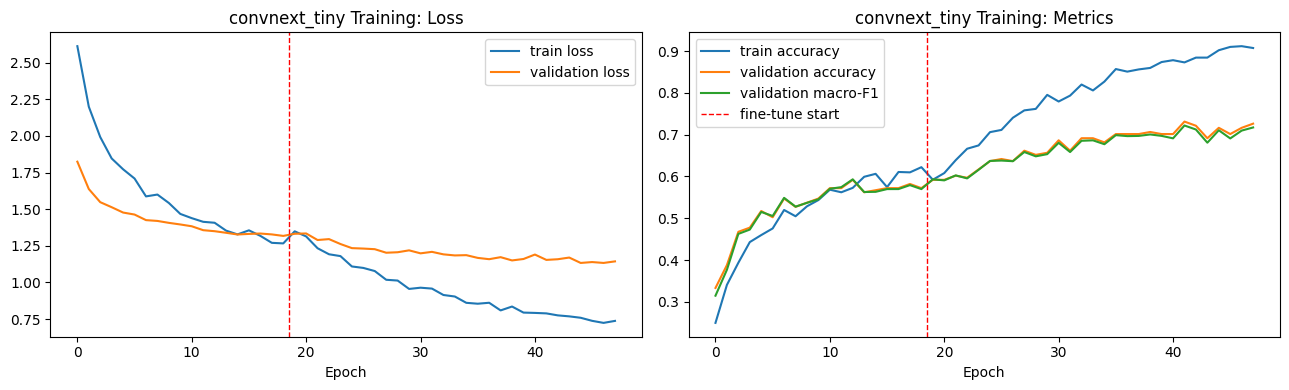

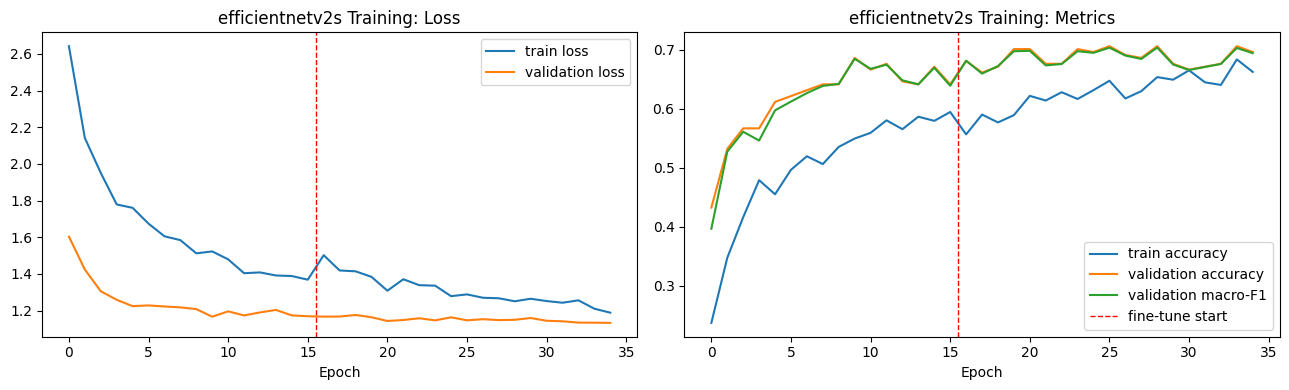

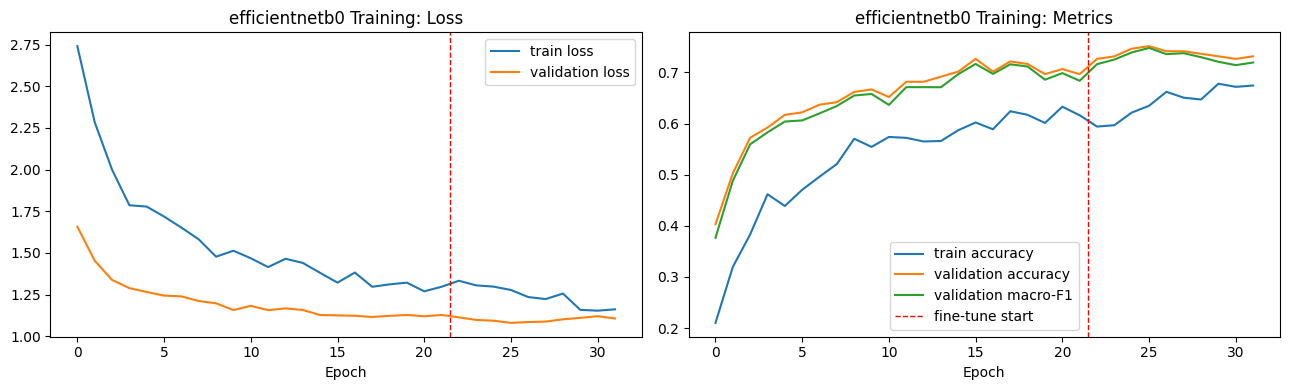

,strategy,accuracy,macro_f1,weighted_f1
0,efficientnetb0 flip-TTA softmax,0.746269,0.742868,0.743699
1,convnext_tiny flip-TTA softmax,0.721393,0.712740,0.714020
2,efficientnetv2s flip-TTA softmax,0.691542,0.688427,0.690260


[I 2026-05-04 00:09:38,032] A new study created in memory with name: no-name-4a7ff248-502d-496c-99a6-3384c322741d


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-05-04 00:09:38,048] Trial 0 finished with value: 0.7894270094186366 and parameters: {'w_convnext_tiny': 0.3745401188473625, 'w_efficientnetv2s': 0.9507143064099162, 'w_efficientnetb0': 0.7319939418114051}. Best is trial 0 with value: 0.7894270094186366.
[I 2026-05-04 00:09:38,054] Trial 1 finished with value: 0.7569190660760429 and parameters: {'w_convnext_tiny': 0.5986584841970366, 'w_efficientnetv2s': 0.15601864044243652, 'w_efficientnetb0': 0.15599452033620265}. Best is trial 0 with value: 0.7894270094186366.
[I 2026-05-04 00:09:38,061] Trial 2 finished with value: 0.7885208201303235 and parameters: {'w_convnext_tiny': 0.05808361216819946, 'w_efficientnetv2s': 0.8661761457749352, 'w_efficientnetb0': 0.6011150117432088}. Best is trial 0 with value: 0.7894270094186366.
[I 2026-05-04 00:09:38,068] Trial 3 finished with value: 0.7619959355885494 and parameters: {'w_convnext_tiny': 0.7080725777960455, 'w_efficientnetv2s': 0.020584494295802447, 'w_efficientnetb0': 0.96990985216199

,strategy,macro_f1,accuracy,weighted_f1,w_convnext_tiny,w_efficientnetv2s,w_efficientnetb0
0,optuna weighted ensemble,0.809804,0.815920,0.811829,0.048018,0.533494,0.418488
1,optuna weighted ensemble,0.809728,0.815920,0.811688,0.075465,0.527400,0.397135
2,optuna weighted ensemble,0.805674,0.810945,0.807750,0.068181,0.500393,0.431426
3,optuna weighted ensemble,0.805674,0.810945,0.807750,0.044543,0.530530,0.424927
4,optuna weighted ensemble,0.805674,0.810945,0.807750,0.077741,0.486558,0.435701
5,optuna weighted ensemble,0.805674,0.810945,0.807750,0.067931,0.492711,0.439358
6,optuna weighted ensemble,0.805674,0.810945,0.807750,0.085349,0.485168,0.429482
7,optuna weighted ensemble,0.805674,0.810945,0.807750,0.064654,0.495851,0.439494
8,optuna weighted ensemble,0.805674,0.810945,0.807750,0.056749,0.507858,0.435393
9,optuna weighted ensemble,0.805674,0.810945,0.807750,0.078588,0.489889,0.431523


Optuna selected ensemble weights: {'convnext_tiny': 0.048018467060710085, 'efficientnetv2s': 0.5334939083257236, 'efficientnetb0': 0.4184876246135662}


,strategy,accuracy,macro_f1,weighted_f1,w_convnext_tiny,w_efficientnetv2s,w_efficientnetb0,min_weight
0,optuna,0.815920,0.809804,0.811829,0.048018,0.533494,0.418488,0.048018
1,stable_010_045_045,0.800995,0.796313,0.798041,0.100000,0.450000,0.450000,0.100000
2,no_convnext_000_050_050,0.796020,0.791608,0.793633,0.000000,0.500000,0.500000,0.000000
3,stable_020_040_040,0.776119,0.770902,0.772808,0.200000,0.400000,0.400000,0.200000
4,equal_033_033_033,0.766169,0.760877,0.762760,0.333333,0.333333,0.333333,0.333333


Using Optuna ensemble weights; no robust candidate was close enough.
Final selected ensemble strategy: optuna
Final selected ensemble weights: {'convnext_tiny': 0.048018467060710085, 'efficientnetv2s': 0.5334939083257236, 'efficientnetb0': 0.4184876246135662}


,strategy,accuracy,macro_f1,weighted_f1
0,optimized weighted ensemble,0.815920,0.809804,0.811829
1,efficientnetb0 flip-TTA softmax,0.746269,0.742868,0.743699
2,convnext_tiny flip-TTA softmax,0.721393,0.712740,0.714020
3,efficientnetv2s flip-TTA softmax,0.691542,0.688427,0.690260


                           precision    recall  f1-score   support

Black_spiny_tailed_iguana       0.96      0.90      0.93        30
              Brown_anole       0.62      0.79      0.70        29
       Cuban_knight_anole       0.79      0.96      0.87        28
            Desert_iguana       1.00      0.93      0.96        28
              Green_anole       0.75      0.44      0.56        27
             Green_iguana       0.78      0.83      0.81        30
  Lesser_Antillean_iguana       0.86      0.83      0.84        29

                 accuracy                           0.82       201
                macro avg       0.82      0.81      0.81       201
             weighted avg       0.82      0.82      0.81       201



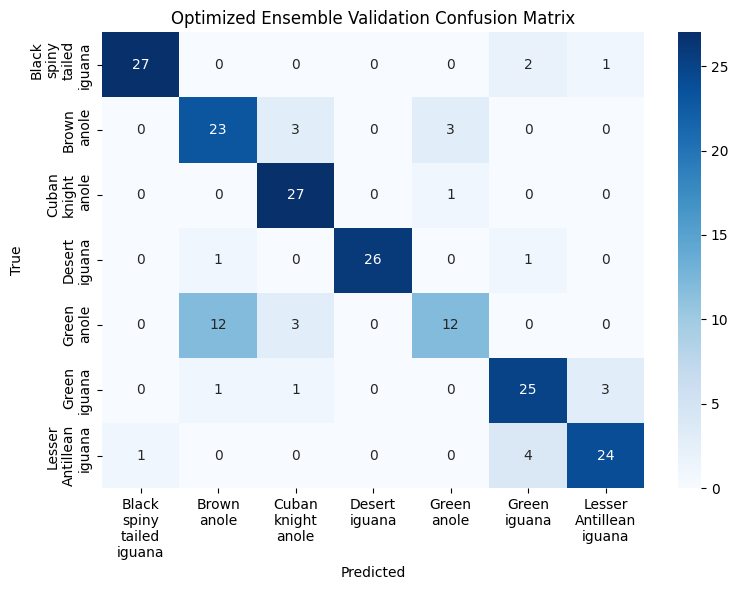

In [13]:
KNN_NEIGHBORS = [1, 3, 5, 7, 9, 11, 13, 15, 21, 31]
KNN_TEMPERATURES = [0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30]
BLEND_ALPHAS = np.linspace(0.0, 1.0, 51)


def plot_history(history_obj, title="Training History"):
    history_dict = history_obj.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_dict.get("loss", []), label="train")
    axes[0].plot(history_dict.get("val_loss", []), label="validation")
    axes[0].set_title(f"{title}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history_dict.get("accuracy", []), label="train accuracy")
    axes[1].plot(history_dict.get("val_accuracy", []), label="validation accuracy")
    if "val_macro_f1" in history_dict:
        axes[1].plot(history_dict["val_macro_f1"], label="validation macro-F1")
    axes[1].set_title(f"{title}: Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_combined_history(head_history, fine_tune_history=None, title="Final Model Training"):
    histories = [head_history.history]
    if fine_tune_history is not None:
        histories.append(fine_tune_history.history)

    def combine_metric(metric):
        combined = []
        for history in histories:
            combined.extend(history.get(metric, []))
        return combined

    fine_tune_start = len(histories[0].get("loss", []))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(combine_metric("loss"), label="train loss")
    axes[0].plot(combine_metric("val_loss"), label="validation loss")
    axes[0].set_title(f"{title}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(combine_metric("accuracy"), label="train accuracy")
    axes[1].plot(combine_metric("val_accuracy"), label="validation accuracy")
    val_macro_f1 = combine_metric("val_macro_f1")
    if val_macro_f1:
        axes[1].plot(val_macro_f1, label="validation macro-F1")
    axes[1].set_title(f"{title}: Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    if fine_tune_history is not None and fine_tune_start > 0:
        for axis in axes:
            axis.axvline(
                x=fine_tune_start - 0.5,
                color="red",
                linestyle="--",
                linewidth=1,
                label="fine-tune start",
            )
        handles, labels = axes[1].get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        axes[1].legend(unique.values(), unique.keys())

    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[name.replace("_", "\n") for name in class_names],
        yticklabels=[name.replace("_", "\n") for name in class_names],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def horizontal_flip_dataset(dataset):
    if isinstance(dataset.element_spec, tuple):
        return dataset.map(
            lambda images, labels: (tf.image.flip_left_right(images), labels),
            num_parallel_calls=AUTOTUNE,
        ).prefetch(AUTOTUNE)
    return dataset.map(lambda images: tf.image.flip_left_right(images), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


def predict_softmax_tta(model, dataset):
    if USE_TTA:
        return (
            model.predict(dataset, verbose=0) + model.predict(horizontal_flip_dataset(dataset), verbose=0)
        ) / 2.0
    return model.predict(dataset, verbose=0)


def build_feature_extractor(model):
    try:
        embedding_output = model.get_layer("embedding_features").output
    except ValueError:
        embedding_output = model.layers[-2].output
    return keras.Model(model.input, embedding_output, name="embedding_extractor")


def extract_embeddings(feature_model, dataset):
    return feature_model.predict(dataset, verbose=0)


def l2_normalize(embeddings):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / np.maximum(norms, 1e-8)


def compute_knn_probabilities(train_embeddings, train_labels, query_embeddings, k, temperature, num_classes):
    k = min(int(k), len(train_labels))
    similarities = query_embeddings @ train_embeddings.T
    top_idx = np.argpartition(-similarities, kth=k - 1, axis=1)[:, :k]
    top_similarities = np.take_along_axis(similarities, top_idx, axis=1)
    order = np.argsort(-top_similarities, axis=1)
    top_idx = np.take_along_axis(top_idx, order, axis=1)
    top_similarities = np.take_along_axis(top_similarities, order, axis=1)

    scaled = top_similarities / max(float(temperature), 1e-6)
    scaled = scaled - scaled.max(axis=1, keepdims=True)
    weights = np.exp(scaled)
    weights = weights / np.maximum(weights.sum(axis=1, keepdims=True), 1e-8)

    probabilities = np.zeros((len(query_embeddings), num_classes), dtype=np.float32)
    for row_idx in range(len(query_embeddings)):
        for neighbour_idx in range(k):
            label = int(train_labels[top_idx[row_idx, neighbour_idx]])
            probabilities[row_idx, label] += float(weights[row_idx, neighbour_idx])
    return probabilities


def metric_summary_from_probabilities(y_true, probabilities, name):
    predictions = probabilities.argmax(axis=1)
    return {
        "strategy": name,
        "accuracy": float(np.mean(predictions == y_true)),
        "macro_f1": float(f1_score(y_true, predictions, average="macro")),
        "weighted_f1": float(f1_score(y_true, predictions, average="weighted")),
    }


def search_inference_strategies(model, feature_model, train_eval_ds, train_labels, selection_ds, selection_labels):
    train_embeddings = l2_normalize(extract_embeddings(feature_model, train_eval_ds))
    selection_embeddings_orig = l2_normalize(extract_embeddings(feature_model, selection_ds))
    selection_embeddings_flip = l2_normalize(extract_embeddings(feature_model, horizontal_flip_dataset(selection_ds)))

    base_probabilities = model.predict(selection_ds, verbose=0)
    flip_probabilities = model.predict(horizontal_flip_dataset(selection_ds), verbose=0)
    tta_probabilities = (base_probabilities + flip_probabilities) / 2.0

    candidates = []

    def register(strategy_name, probabilities, metadata):
        summary = metric_summary_from_probabilities(selection_labels, probabilities, strategy_name)
        candidates.append({"strategy_name": strategy_name, "probabilities": probabilities, "metadata": metadata, **summary})

    register("single-pass softmax", base_probabilities, {"family": "softmax"})
    register("flip-TTA softmax", tta_probabilities, {"family": "softmax_tta"})

    embedding_variants = {
        "orig": selection_embeddings_orig,
        "flip_only": selection_embeddings_flip,
        "flip_avg": l2_normalize((selection_embeddings_orig + selection_embeddings_flip) / 2.0),
    }
    for embedding_variant, query_embeddings in embedding_variants.items():
        for temperature in KNN_TEMPERATURES:
            for k in KNN_NEIGHBORS:
                knn_probabilities = compute_knn_probabilities(
                    train_embeddings=train_embeddings,
                    train_labels=train_labels,
                    query_embeddings=query_embeddings,
                    k=k,
                    temperature=temperature,
                    num_classes=len(class_names),
                )
                register(
                    f"kNN only ({embedding_variant}, k={k}, temp={temperature:.2f})",
                    knn_probabilities,
                    {"family": "knn", "embedding_variant": embedding_variant, "k": k, "temperature": temperature},
                )
                for alpha in BLEND_ALPHAS:
                    blended_probabilities = alpha * tta_probabilities + (1.0 - alpha) * knn_probabilities
                    register(
                        f"blend TTA + kNN ({embedding_variant}, k={k}, temp={temperature:.2f}, alpha={alpha:.2f})",
                        blended_probabilities,
                        {
                            "family": "blend",
                            "embedding_variant": embedding_variant,
                            "k": k,
                            "temperature": temperature,
                            "alpha": float(alpha),
                        },
                    )

    results_df = (
        pd.DataFrame([
            {
                "strategy": candidate["strategy_name"],
                "accuracy": candidate["accuracy"],
                "macro_f1": candidate["macro_f1"],
                "weighted_f1": candidate["weighted_f1"],
            }
            for candidate in candidates
        ])
        .sort_values(["macro_f1", "accuracy"], ascending=False)
        .reset_index(drop=True)
    )
    best_candidate = max(candidates, key=lambda item: (item["macro_f1"], item["accuracy"]))
    assets = {"train_embeddings": train_embeddings, "train_labels": np.asarray(train_labels)}
    return results_df, best_candidate, assets


def predict_with_inference_strategy(model, feature_model, dataset, metadata, train_embeddings, train_labels):
    base_probabilities = model.predict(dataset, verbose=0)
    if metadata.get("family") == "softmax":
        return base_probabilities

    flip_probabilities = model.predict(horizontal_flip_dataset(dataset), verbose=0)
    tta_probabilities = (base_probabilities + flip_probabilities) / 2.0
    if metadata.get("family") == "softmax_tta":
        return tta_probabilities

    embeddings_orig = l2_normalize(extract_embeddings(feature_model, dataset))
    embeddings_flip = l2_normalize(extract_embeddings(feature_model, horizontal_flip_dataset(dataset)))
    embedding_variant = metadata.get("embedding_variant", "orig")
    if embedding_variant == "flip_only":
        query_embeddings = embeddings_flip
    elif embedding_variant == "flip_avg":
        query_embeddings = l2_normalize((embeddings_orig + embeddings_flip) / 2.0)
    else:
        query_embeddings = embeddings_orig

    knn_probabilities = compute_knn_probabilities(
        train_embeddings=train_embeddings,
        train_labels=train_labels,
        query_embeddings=query_embeddings,
        k=metadata["k"],
        temperature=metadata["temperature"],
        num_classes=len(class_names),
    )
    if metadata.get("family") == "knn":
        return knn_probabilities

    alpha = float(metadata["alpha"])
    return alpha * tta_probabilities + (1.0 - alpha) * knn_probabilities


for backbone_name, histories in training_histories.items():
    if histories["head"] is not None:
        plot_combined_history(
            histories["head"],
            histories["fine_tune"],
            title=f"{backbone_name} Training",
        )


def load_trained_model(backbone_name):
    model = keras.models.load_model(trained_model_paths[backbone_name], compile=False)
    model._backbone_name = backbone_name
    return model


def collect_backbone_probabilities(dataset):
    probabilities = {}
    for backbone_name in ACTIVE_ENSEMBLE_BACKBONES:
        model = load_trained_model(backbone_name)
        probabilities[backbone_name] = predict_softmax_tta(model, dataset)
        del model
        gc.collect()
        keras.backend.clear_session()
    return probabilities


def blend_probabilities(probabilities_by_backbone, weights):
    blended = None
    total_weight = 0.0
    for backbone_name in ACTIVE_ENSEMBLE_BACKBONES:
        weight = float(weights.get(backbone_name, 0.0))
        if weight <= 0:
            continue
        model_probabilities = probabilities_by_backbone[backbone_name]
        blended = model_probabilities * weight if blended is None else blended + model_probabilities * weight
        total_weight += weight
    if blended is None or total_weight <= 0:
        raise ValueError("At least one ensemble weight must be positive.")
    return blended / total_weight


def evaluate_ensemble_weights(probabilities_by_backbone, labels, weights, name="ensemble"):
    probabilities = blend_probabilities(probabilities_by_backbone, weights)
    summary = metric_summary_from_probabilities(labels, probabilities, name)
    return {**summary, **{f"w_{backbone_name}": float(weights.get(backbone_name, 0.0)) for backbone_name in ACTIVE_ENSEMBLE_BACKBONES}, "probabilities": probabilities}


def normalize_ensemble_weights(raw_weights):
    active_backbones = [
        backbone_name for backbone_name in ACTIVE_ENSEMBLE_BACKBONES
        if backbone_name in raw_weights
    ]
    if not active_backbones:
        active_backbones = list(raw_weights)
    total = sum(max(0.0, float(raw_weights.get(backbone_name, 0.0))) for backbone_name in active_backbones)
    if total <= 0:
        return {backbone_name: 1.0 / len(active_backbones) for backbone_name in active_backbones}
    return {
        backbone_name: max(0.0, float(raw_weights.get(backbone_name, 0.0))) / total
        for backbone_name in active_backbones
    }


def optuna_search_ensemble_weights(probabilities_by_backbone, labels, n_trials=300):
    trials = []

    def objective(trial):
        raw_weights = {
            backbone_name: trial.suggest_float(f"w_{backbone_name}", 0.0, 1.0)
            for backbone_name in ACTIVE_ENSEMBLE_BACKBONES
        }
        weights = normalize_ensemble_weights(raw_weights)
        probabilities = blend_probabilities(probabilities_by_backbone, weights)
        predictions = probabilities.argmax(axis=1)
        macro_f1 = float(f1_score(labels, predictions, average="macro"))
        accuracy = float(np.mean(predictions == labels))
        weighted_f1 = float(f1_score(labels, predictions, average="weighted"))
        trial.set_user_attr("weights", weights)
        trial.set_user_attr("accuracy", accuracy)
        trial.set_user_attr("weighted_f1", weighted_f1)
        trials.append(
            {
                "strategy": "optuna weighted ensemble",
                "macro_f1": macro_f1,
                "accuracy": accuracy,
                "weighted_f1": weighted_f1,
                **{f"w_{backbone_name}": weights[backbone_name] for backbone_name in ACTIVE_ENSEMBLE_BACKBONES},
            }
        )
        return macro_f1

    sampler = optuna.samplers.TPESampler(seed=SEED, multivariate=True)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=int(n_trials), show_progress_bar=True)
    results_df = pd.DataFrame(trials).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
    best_weights = dict(study.best_trial.user_attrs["weights"])
    return study, results_df, best_weights


val_probabilities_by_backbone = collect_backbone_probabilities(final_val_ds)

single_model_validation_table = pd.DataFrame([
    metric_summary_from_probabilities(final_val_labels, val_probabilities_by_backbone[backbone_name], f"{backbone_name} flip-TTA softmax")
    for backbone_name in ACTIVE_ENSEMBLE_BACKBONES
]).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
display(single_model_validation_table)

ensemble_weight_study, ensemble_results_df, selected_ensemble_weights = optuna_search_ensemble_weights(
    val_probabilities_by_backbone,
    final_val_labels,
    n_trials=ENSEMBLE_WEIGHT_OPTUNA_TRIALS,
)
ENSEMBLE_WEIGHTS.update(selected_ensemble_weights)

print(f"Best Optuna ensemble macro-F1: {ensemble_weight_study.best_value:.4f}")
print("Top Optuna ensemble weights:")
display(ensemble_results_df.head(10))
print("Optuna selected ensemble weights:", selected_ensemble_weights)

robust_candidate_rows = []
for candidate_name, candidate_weights in ENSEMBLE_ROBUST_CANDIDATE_WEIGHTS.items():
    weights = selected_ensemble_weights if candidate_weights is None else normalize_ensemble_weights(candidate_weights)
    summary = evaluate_ensemble_weights(
        val_probabilities_by_backbone,
        final_val_labels,
        weights,
        name=candidate_name,
    )
    summary.pop("probabilities", None)
    summary["min_weight"] = min(weights.get(backbone_name, 0.0) for backbone_name in ACTIVE_ENSEMBLE_BACKBONES)
    robust_candidate_rows.append(summary)

robust_candidate_results_df = pd.DataFrame(robust_candidate_rows).sort_values(
    ["macro_f1", "accuracy", "min_weight"],
    ascending=False,
).reset_index(drop=True)
display(robust_candidate_results_df)

optuna_macro_f1 = float(robust_candidate_results_df.loc[robust_candidate_results_df["strategy"] == "optuna", "macro_f1"].iloc[0])
if ENSEMBLE_SELECTION_MODE == "manual":
    selected_ensemble_weights = normalize_ensemble_weights(MANUAL_ENSEMBLE_WEIGHTS)
    selected_ensemble_strategy = "manual_optuna_weights"
    print("Using manual ensemble weights:", selected_ensemble_weights)
elif ENSEMBLE_SELECTION_MODE == "optuna":
    selected_ensemble_strategy = "optuna"
    print("Using raw Optuna ensemble weights.")
elif ENSEMBLE_SELECTION_MODE == "robust":
    robust_close_candidates = robust_candidate_results_df[
        (robust_candidate_results_df["strategy"] != "optuna")
        & (robust_candidate_results_df["macro_f1"] >= optuna_macro_f1 - ENSEMBLE_ROBUST_SELECTION_TOLERANCE)
    ].copy()
    if len(robust_close_candidates) > 0:
        chosen_row = robust_close_candidates.sort_values(
            ["macro_f1", "min_weight", "accuracy"],
            ascending=False,
        ).iloc[0]
        selected_ensemble_weights = {
            backbone_name: float(chosen_row[f"w_{backbone_name}"])
            for backbone_name in ACTIVE_ENSEMBLE_BACKBONES
        }
        selected_ensemble_strategy = str(chosen_row["strategy"])
        print(
            f"Using robust ensemble weights from {selected_ensemble_strategy}; "
            f"within {ENSEMBLE_ROBUST_SELECTION_TOLERANCE:.3f} macro-F1 of Optuna."
        )
    else:
        selected_ensemble_strategy = "optuna"
        print("Using Optuna ensemble weights; no robust candidate was close enough.")
else:
    raise ValueError(f"Unsupported ENSEMBLE_SELECTION_MODE: {ENSEMBLE_SELECTION_MODE}")
ENSEMBLE_WEIGHTS.update(selected_ensemble_weights)
print("Final selected ensemble strategy:", selected_ensemble_strategy)
print("Final selected ensemble weights:", selected_ensemble_weights)

final_val_probabilities = blend_probabilities(val_probabilities_by_backbone, selected_ensemble_weights)
final_val_predictions = final_val_probabilities.argmax(axis=1)

validation_metric_table = pd.concat(
    [
        single_model_validation_table,
        pd.DataFrame([
            metric_summary_from_probabilities(final_val_labels, final_val_probabilities, "optimized weighted ensemble")
        ]),
    ],
    ignore_index=True,
).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
display(validation_metric_table)

print(classification_report(final_val_labels, final_val_predictions, target_names=class_names))
plot_confusion(final_val_labels, final_val_predictions, title="Optimized Ensemble Validation Confusion Matrix")

## 7. Submission

In [14]:
def predict_weighted_ensemble(dataset, model_paths=None, weights=None):
    model_paths = model_paths or trained_model_paths
    weights = weights or selected_ensemble_weights
    missing = [backbone_name for backbone_name in ACTIVE_ENSEMBLE_BACKBONES if backbone_name not in model_paths]
    if missing:
        raise ValueError(f"Missing ensemble checkpoints for: {missing}")

    probabilities = None
    total_weight = 0.0
    for backbone_name in ACTIVE_ENSEMBLE_BACKBONES:
        model_path = Path(model_paths[backbone_name])
        if not model_path.exists():
            raise FileNotFoundError(f"Checkpoint for {backbone_name} not found at {model_path}")

        ensemble_model = keras.models.load_model(model_path, compile=False)
        weight = float(weights.get(backbone_name, 0.0))
        model_probabilities = predict_softmax_tta(ensemble_model, dataset)
        probabilities = model_probabilities * weight if probabilities is None else probabilities + model_probabilities * weight
        total_weight += weight
        print(f"Added {backbone_name} to ensemble with weight {weight:.3f}.")
        del ensemble_model
        gc.collect()
        keras.backend.clear_session()

    if probabilities is None or total_weight <= 0:
        raise ValueError("No positive ensemble weights were found.")
    return probabilities / total_weight


test_ds = make_inference_dataset(test_df, batch_size=best_batch_size)

test_probabilities = predict_weighted_ensemble(test_ds)
print("Submission inference strategy: optimized weighted backbone ensemble")
print("Submission ensemble strategy:", selected_ensemble_strategy)
print("Submission ensemble weights:", selected_ensemble_weights)

submission = test_df[["id"]].copy()
submission["label"] = test_probabilities.argmax(axis=1).astype(int)

submission_path = WORKING_ROOT / "submission.csv"
submission.to_csv(submission_path, index=False)

print("Saved submission to:", submission_path)
print(submission.head())

Added convnext_tiny to ensemble with weight 0.048.
Added efficientnetv2s to ensemble with weight 0.533.
Added efficientnetb0 to ensemble with weight 0.418.
Submission inference strategy: optimized weighted backbone ensemble
Submission ensemble strategy: optuna
Submission ensemble weights: {'convnext_tiny': 0.048018467060710085, 'efficientnetv2s': 0.5334939083257236, 'efficientnetb0': 0.4184876246135662}
Saved submission to: /kaggle/working/submission.csv
   id  label
0   1      6
1   2      5
2   3      2
3   4      5
4   5      0


In [ ]:
# Optional combined ensemble export + Cleanlab-ready Brown/Green review exports.
# This cell does not retrain or overwrite the three separate backbone checkpoints.

import json
from pathlib import Path

CREATE_COMBINED_ENSEMBLE_MODEL = True
EXPORT_CLEANLAB_REVIEW_FILES = True

REPORT_DIR = Path(globals().get("REPORT_DIR", Path(WORKING_ROOT) / "reports"))
REPORT_DIR.mkdir(parents=True, exist_ok=True)


def _normalised_id_to_class():
    if "id_to_class" in globals():
        return {int(class_id): str(class_name) for class_id, class_name in id_to_class.items()}
    if "class_to_id" in globals():
        return {int(class_id): str(class_name) for class_name, class_id in class_to_id.items()}
    if "class_names" in globals():
        return {int(class_id): str(class_name) for class_id, class_name in enumerate(class_names)}
    raise NameError("Could not find id_to_class, class_to_id, or class_names for Cleanlab export.")


id_to_class = _normalised_id_to_class()
class_to_id = {class_name: class_id for class_id, class_name in id_to_class.items()}
class_names_for_export = [id_to_class[class_id] for class_id in sorted(id_to_class)]


if CREATE_COMBINED_ENSEMBLE_MODEL:
    @keras.utils.register_keras_serializable(package="Lizard")
    class HorizontalFlip(layers.Layer):
        def call(self, inputs):
            return tf.image.flip_left_right(inputs)


    @keras.utils.register_keras_serializable(package="Lizard")
    class WeightedProbabilityEnsemble(layers.Layer):
        def __init__(self, weights, **kwargs):
            super().__init__(**kwargs)
            self.ensemble_weights = [float(weight) for weight in weights]

        def call(self, inputs):
            if len(inputs) != len(self.ensemble_weights):
                raise ValueError("The number of probability tensors must match the number of weights.")
            total_weight = float(sum(self.ensemble_weights))
            if total_weight <= 0:
                raise ValueError("At least one ensemble weight must be positive.")

            blended = tf.zeros_like(tf.cast(inputs[0], tf.float32))
            for probability_tensor, weight in zip(inputs, self.ensemble_weights):
                blended = blended + tf.cast(probability_tensor, tf.float32) * tf.cast(weight, tf.float32)
            return blended / tf.cast(total_weight, tf.float32)

        def get_config(self):
            config = super().get_config()
            config.update({"weights": self.ensemble_weights})
            return config


    @keras.utils.register_keras_serializable(package="Lizard")
    class AverageProbabilities(layers.Layer):
        def call(self, inputs):
            if len(inputs) != 2:
                raise ValueError("AverageProbabilities expects exactly two tensors.")
            return (tf.cast(inputs[0], tf.float32) + tf.cast(inputs[1], tf.float32)) / 2.0


    def _load_frozen_submodel(backbone_name):
        if backbone_name not in trained_model_paths:
            raise KeyError(f"Missing checkpoint path for {backbone_name} in trained_model_paths.")
        model_path = Path(trained_model_paths[backbone_name])
        if not model_path.exists():
            raise FileNotFoundError(f"Checkpoint for {backbone_name} not found at {model_path}")

        submodel = keras.models.load_model(model_path, compile=False)
        submodel.trainable = False
        for layer in submodel.layers:
            layer.trainable = False
        try:
            submodel._name = f"ensemble_submodel_{backbone_name}"
        except Exception:
            pass
        return submodel


    def _weighted_ensemble_branch(images, submodels, weights, branch_name):
        branch_probabilities = []
        for backbone_name in ACTIVE_ENSEMBLE_BACKBONES:
            probabilities = submodels[backbone_name](images, training=False)
            probabilities = layers.Activation(
                "linear",
                dtype="float32",
                name=f"{branch_name}_{backbone_name}_probabilities_float32",
            )(probabilities)
            branch_probabilities.append(probabilities)
        return WeightedProbabilityEnsemble(
            [weights[backbone_name] for backbone_name in ACTIVE_ENSEMBLE_BACKBONES],
            name=f"{branch_name}_weighted_probability_ensemble",
        )(branch_probabilities)


    print("Selected ensemble weights:", selected_ensemble_weights)

    ensemble_weights_for_model = normalize_ensemble_weights(
        {backbone_name: float(selected_ensemble_weights.get(backbone_name, 0.0)) for backbone_name in ACTIVE_ENSEMBLE_BACKBONES}
    )
    ensemble_submodels = {
        backbone_name: _load_frozen_submodel(backbone_name)
        for backbone_name in ACTIVE_ENSEMBLE_BACKBONES
    }

    ensemble_input = keras.Input(shape=(*IMG_SIZE, 3), name="image")
    normal_probabilities = _weighted_ensemble_branch(
        ensemble_input,
        ensemble_submodels,
        ensemble_weights_for_model,
        branch_name="normal",
    )
    flipped_input = HorizontalFlip(name="flip_tta_horizontal_flip")(ensemble_input)
    flipped_probabilities = _weighted_ensemble_branch(
        flipped_input,
        ensemble_submodels,
        ensemble_weights_for_model,
        branch_name="flipped",
    )
    ensemble_output = AverageProbabilities(name="flip_tta_probability_average")(
        [normal_probabilities, flipped_probabilities]
    )

    combined_ensemble_model = keras.Model(
        ensemble_input,
        ensemble_output,
        name="lizard_weighted_ensemble_flip_tta",
    )
    combined_model_path = Path(WORKING_ROOT) / "lizard_weighted_ensemble_flip_tta.keras"
    combined_ensemble_model.save(combined_model_path)

    reloaded_combined_model = keras.models.load_model(
        combined_model_path,
        compile=False,
        custom_objects={
            "HorizontalFlip": HorizontalFlip,
            "WeightedProbabilityEnsemble": WeightedProbabilityEnsemble,
            "AverageProbabilities": AverageProbabilities,
        },
    )

    if "final_val_probabilities" in globals():
        reference_val_probabilities = np.asarray(final_val_probabilities, dtype=np.float32)
    else:
        reference_val_probabilities = blend_probabilities(
            collect_backbone_probabilities(final_val_ds),
            selected_ensemble_weights,
        ).astype(np.float32)

    combined_val_probabilities = reloaded_combined_model.predict(final_val_ds, verbose=0).astype(np.float32)
    prediction_differences = np.abs(reference_val_probabilities - combined_val_probabilities)
    identical_class_percentage = 100.0 * np.mean(
        reference_val_probabilities.argmax(axis=1) == combined_val_probabilities.argmax(axis=1)
    )

    print("Saved combined model path:", combined_model_path)
    print(f"Combined model file size: {combined_model_path.stat().st_size / (1024 ** 2):.2f} MB")
    print(f"Max absolute prediction difference: {prediction_differences.max():.8f}")
    print(f"Mean absolute prediction difference: {prediction_differences.mean():.8f}")
    print(f"Identical predicted classes: {identical_class_percentage:.2f}%")


if EXPORT_CLEANLAB_REVIEW_FILES:
    exported_paths = []

    if "final_holdout_probabilities" in globals() and "final_y_true" in globals():
        pred_probs = np.asarray(final_holdout_probabilities, dtype=np.float32)
        y_true = np.asarray(final_y_true, dtype=np.int64)
        cleanlab_source_name = "holdout"
    elif "final_val_probabilities" in globals() and "final_val_labels" in globals():
        pred_probs = np.asarray(final_val_probabilities, dtype=np.float32)
        y_true = np.asarray(final_val_labels, dtype=np.int64)
        cleanlab_source_name = "validation"
    elif "final_val_labels" in globals():
        pred_probs = blend_probabilities(
            collect_backbone_probabilities(final_val_ds),
            selected_ensemble_weights,
        ).astype(np.float32)
        y_true = np.asarray(final_val_labels, dtype=np.int64)
        cleanlab_source_name = "validation"
    else:
        raise NameError("Could not find final holdout or validation probabilities/labels for Cleanlab export.")

    if len(pred_probs) != len(y_true):
        raise ValueError(f"pred_probs length ({len(pred_probs)}) does not match y_true length ({len(y_true)}).")

    def _matching_results_dataframe(source_name, labels):
        if "final_results_df" in globals() and len(final_results_df) == len(labels):
            return final_results_df.copy()

        candidate_names = []
        if source_name == "holdout":
            candidate_names.extend(["holdout_test_df", "holdout_df", "final_holdout_df", "val_df"])
        else:
            candidate_names.extend(["val_df", "final_val_df", "validation_df", "holdout_test_df"])

        for candidate_name in candidate_names:
            candidate = globals().get(candidate_name)
            if isinstance(candidate, pd.DataFrame) and len(candidate) == len(labels) and "filepath" in candidate.columns:
                return candidate.copy()
        raise NameError("Could not find a matching dataframe with filepath values for Cleanlab export.")

    results_df = _matching_results_dataframe(cleanlab_source_name, y_true).reset_index(drop=True)
    results_df["filepath"] = results_df["filepath"].astype(str)
    results_df["label"] = y_true.astype(int)
    results_df["label_name"] = results_df["label"].map(id_to_class)
    results_df["_cleanlab_row_id"] = np.arange(len(results_df), dtype=np.int64)

    pred_labels = pred_probs.argmax(axis=1).astype(np.int64)
    pred_confidence = pred_probs[np.arange(len(pred_probs)), pred_labels]
    true_label_probability = pred_probs[np.arange(len(pred_probs)), y_true]

    brown_class_name = "Brown_anole"
    green_class_name = "Green_anole"
    missing_target_classes = [name for name in [brown_class_name, green_class_name] if name not in class_to_id]
    if missing_target_classes:
        raise KeyError(f"Missing Brown/Green target classes in class mapping: {missing_target_classes}")

    brown_id = int(class_to_id[brown_class_name])
    green_id = int(class_to_id[green_class_name])
    target_class_ids = {brown_id, green_id}
    target_class_names = {brown_class_name, green_class_name}

    cleanlab_pred_probs_path = REPORT_DIR / "cleanlab_pred_probs.npy"
    cleanlab_true_labels_path = REPORT_DIR / "cleanlab_true_labels.npy"
    cleanlab_class_names_path = REPORT_DIR / "cleanlab_class_names.json"
    cleanlab_review_predictions_path = REPORT_DIR / "cleanlab_review_predictions.csv"
    cleanlab_label_issues_path = REPORT_DIR / "cleanlab_label_issues.csv"
    cleanlab_brown_green_review_path = REPORT_DIR / "cleanlab_brown_green_anole_review.csv"

    np.save(cleanlab_pred_probs_path, pred_probs)
    np.save(cleanlab_true_labels_path, y_true)
    with open(cleanlab_class_names_path, "w", encoding="utf-8") as file:
        json.dump(class_names_for_export, file, indent=2)
    exported_paths.extend([cleanlab_pred_probs_path, cleanlab_true_labels_path, cleanlab_class_names_path])

    review_predictions = pd.DataFrame(
        {
            "_cleanlab_row_id": results_df["_cleanlab_row_id"].values,
            "filepath": results_df["filepath"].values,
            "filename": results_df["filepath"].map(lambda path: Path(path).name).values,
            "true_label_id": y_true.astype(int),
            "true_label_name": [id_to_class[int(label)] for label in y_true],
            "predicted_label_id": pred_labels.astype(int),
            "predicted_label_name": [id_to_class[int(label)] for label in pred_labels],
            "predicted_confidence": pred_confidence,
            "true_label_probability": true_label_probability,
            "brown_anole_probability": pred_probs[:, brown_id],
            "green_anole_probability": pred_probs[:, green_id],
        }
    )
    review_predictions["brown_green_probability_gap"] = (
        review_predictions["brown_anole_probability"] - review_predictions["green_anole_probability"]
    )
    review_predictions["brown_green_probability_sum"] = (
        review_predictions["brown_anole_probability"] + review_predictions["green_anole_probability"]
    )
    review_predictions["is_brown_or_green_true_label"] = review_predictions["true_label_id"].isin(target_class_ids)
    review_predictions["is_brown_or_green_predicted_label"] = review_predictions["predicted_label_id"].isin(target_class_ids)
    review_predictions["brown_green_confusion"] = (
        ((review_predictions["true_label_id"] == brown_id) & (review_predictions["predicted_label_id"] == green_id))
        | ((review_predictions["true_label_id"] == green_id) & (review_predictions["predicted_label_id"] == brown_id))
    )
    review_predictions["correct"] = review_predictions["true_label_id"] == review_predictions["predicted_label_id"]

    review_prediction_columns = [
        "filepath",
        "filename",
        "true_label_id",
        "true_label_name",
        "predicted_label_id",
        "predicted_label_name",
        "predicted_confidence",
        "true_label_probability",
        "brown_anole_probability",
        "green_anole_probability",
        "brown_green_probability_gap",
        "is_brown_or_green_true_label",
        "is_brown_or_green_predicted_label",
        "brown_green_confusion",
        "correct",
    ]
    review_predictions[review_prediction_columns].to_csv(cleanlab_review_predictions_path, index=False)
    exported_paths.append(cleanlab_review_predictions_path)

    cleanlab_enrichment = None
    try:
        from cleanlab.filter import find_label_issues

        label_issue_indices = find_label_issues(
            labels=y_true,
            pred_probs=pred_probs,
            return_indices_ranked_by="self_confidence",
        )

        issue_probabilities = pred_probs[label_issue_indices]
        issue_true_labels = y_true[label_issue_indices]
        issue_pred_labels = issue_probabilities.argmax(axis=1)
        issue_true_confidence = issue_probabilities[np.arange(len(issue_probabilities)), issue_true_labels]
        issue_pred_confidence = issue_probabilities[np.arange(len(issue_probabilities)), issue_pred_labels]

        cleanlab_issues = results_df.iloc[label_issue_indices].copy().reset_index(drop=True)
        cleanlab_issues["cleanlab_rank"] = np.arange(1, len(cleanlab_issues) + 1)
        cleanlab_issues["current_label"] = cleanlab_issues["label_name"]
        cleanlab_issues["suggested_label"] = [id_to_class[int(label)] for label in issue_pred_labels]
        cleanlab_issues["current_label_probability"] = issue_true_confidence
        cleanlab_issues["suggested_label_probability"] = issue_pred_confidence
        cleanlab_issues["issue_score"] = 1.0 - cleanlab_issues["current_label_probability"]
        cleanlab_issues["filename"] = cleanlab_issues["filepath"].apply(lambda path: Path(path).name)
        cleanlab_issues["needs_review"] = cleanlab_issues["current_label"] != cleanlab_issues["suggested_label"]
        cleanlab_issues = cleanlab_issues.sort_values(
            ["needs_review", "issue_score"],
            ascending=[False, False],
        )
        cleanlab_enrichment = cleanlab_issues[
            [
                "_cleanlab_row_id",
                "cleanlab_rank",
                "suggested_label",
                "suggested_label_probability",
                "issue_score",
                "needs_review",
            ]
        ].copy()
        cleanlab_issues = cleanlab_issues[
            [
                "cleanlab_rank",
                "filename",
                "filepath",
                "current_label",
                "suggested_label",
                "current_label_probability",
                "suggested_label_probability",
                "issue_score",
                "needs_review",
            ]
        ]
        cleanlab_issues.to_csv(cleanlab_label_issues_path, index=False)
        exported_paths.append(cleanlab_label_issues_path)
        print(f"Potential label issues found: {len(cleanlab_issues)}")
    except ImportError:
        print("Cleanlab is not installed. Exported probabilities, labels, and Brown/Green review files only.")

    brown_green_source_df = review_predictions.copy()
    if cleanlab_enrichment is not None:
        brown_green_source_df = brown_green_source_df.merge(
            cleanlab_enrichment,
            on="_cleanlab_row_id",
            how="left",
        )
        cleanlab_suggests_brown_or_green = brown_green_source_df["suggested_label"].isin(target_class_names)
    else:
        cleanlab_suggests_brown_or_green = pd.Series(False, index=brown_green_source_df.index)

    brown_green_focus_mask = (
        brown_green_source_df["true_label_id"].isin(target_class_ids)
        | brown_green_source_df["predicted_label_id"].isin(target_class_ids)
        | cleanlab_suggests_brown_or_green
    )
    brown_green_review = brown_green_source_df.loc[brown_green_focus_mask].copy()

    def _review_reason(row):
        if row["true_label_id"] == brown_id and row["predicted_label_id"] == green_id:
            return "true_brown_pred_green"
        if row["true_label_id"] == green_id and row["predicted_label_id"] == brown_id:
            return "true_green_pred_brown"
        if row["true_label_id"] in target_class_ids:
            return "true_brown_or_green"
        if row["predicted_label_id"] in target_class_ids:
            return "pred_brown_or_green"
        if "suggested_label" in row.index and row.get("suggested_label") in target_class_names:
            return "cleanlab_suggests_brown_or_green"
        return "brown_green_review"

    brown_green_review["review_reason"] = brown_green_review.apply(_review_reason, axis=1)
    brown_green_review["_absolute_brown_green_probability_gap"] = brown_green_review[
        "brown_green_probability_gap"
    ].abs()
    brown_green_review = brown_green_review.sort_values(
        [
            "brown_green_confusion",
            "predicted_confidence",
            "true_label_probability",
            "_absolute_brown_green_probability_gap",
        ],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)

    brown_green_review_columns = [
        "filepath",
        "filename",
        "true_label_id",
        "true_label_name",
        "predicted_label_id",
        "predicted_label_name",
        "predicted_confidence",
        "true_label_probability",
        "brown_anole_probability",
        "green_anole_probability",
        "brown_green_probability_gap",
        "brown_green_probability_sum",
        "brown_green_confusion",
        "correct",
        "review_reason",
    ]
    if cleanlab_enrichment is not None:
        brown_green_review_columns.extend(
            [
                "cleanlab_rank",
                "suggested_label",
                "suggested_label_probability",
                "issue_score",
                "needs_review",
            ]
        )

    brown_green_review[brown_green_review_columns].to_csv(cleanlab_brown_green_review_path, index=False)
    exported_paths.append(cleanlab_brown_green_review_path)

    true_brown_mask = y_true == brown_id
    true_green_mask = y_true == green_id
    brown_predicted_as_green_count = int(np.sum(true_brown_mask & (pred_labels == green_id)))
    green_predicted_as_brown_count = int(np.sum(true_green_mask & (pred_labels == brown_id)))
    average_brown_probability_for_true_brown = float(pred_probs[true_brown_mask, brown_id].mean()) if np.any(true_brown_mask) else np.nan
    average_green_probability_for_true_green = float(pred_probs[true_green_mask, green_id].mean()) if np.any(true_green_mask) else np.nan

    print("Brown/Green Cleanlab export summary:")
    print(f"Brown_anole true samples: {int(true_brown_mask.sum())}")
    print(f"Green_anole true samples: {int(true_green_mask.sum())}")
    print(f"Brown_anole predicted as Green_anole count: {brown_predicted_as_green_count}")
    print(f"Green_anole predicted as Brown_anole count: {green_predicted_as_brown_count}")
    print(f"Average Brown_anole probability for true Brown_anole samples: {average_brown_probability_for_true_brown:.6f}")
    print(f"Average Green_anole probability for true Green_anole samples: {average_green_probability_for_true_green:.6f}")

    print("Exported Cleanlab review files:")
    for exported_path in exported_paths:
        print(exported_path)


In [ ]:
# Export validation probabilities for local ensemble experiments.
# This cell only saves existing notebook variables. It does not load models, predict, or retrain.

import json
from pathlib import Path

EXPORT_VALIDATION_PROBABILITIES = True

if EXPORT_VALIDATION_PROBABILITIES:
    if "val_probabilities_by_backbone" not in globals():
        raise NameError(
            "val_probabilities_by_backbone does not exist yet. Run the ensemble evaluation cell first; "
            "this export cell will not recompute predictions."
        )
    if "final_val_labels" not in globals():
        raise NameError("final_val_labels does not exist yet. Run the final training/evaluation setup cells first.")

    validation_export_dir = Path(WORKING_ROOT)
    validation_export_dir.mkdir(parents=True, exist_ok=True)

    val_probabilities_by_backbone_path = validation_export_dir / "val_probabilities_by_backbone.npz"
    final_val_labels_path = validation_export_dir / "final_val_labels.npy"
    final_val_probabilities_path = validation_export_dir / "final_val_probabilities.npy"
    val_metadata_path = validation_export_dir / "validation_probability_metadata.json"
    val_rows_path = validation_export_dir / "validation_rows.csv"

    probabilities_to_save = {
        str(backbone_name): np.asarray(probabilities, dtype=np.float32)
        for backbone_name, probabilities in val_probabilities_by_backbone.items()
    }
    np.savez_compressed(val_probabilities_by_backbone_path, **probabilities_to_save)
    np.save(final_val_labels_path, np.asarray(final_val_labels, dtype=np.int64))

    if "final_val_probabilities" in globals():
        np.save(final_val_probabilities_path, np.asarray(final_val_probabilities, dtype=np.float32))

    id_to_class_for_export = {
        int(class_id): str(class_name)
        for class_id, class_name in globals().get("id_to_class", {}).items()
    }
    if not id_to_class_for_export and "class_names" in globals():
        id_to_class_for_export = {int(class_id): str(class_name) for class_id, class_name in enumerate(class_names)}

    metadata = {
        "backbones": list(probabilities_to_save.keys()),
        "num_validation_samples": int(len(final_val_labels)),
        "probability_shapes": {
            backbone_name: list(probabilities.shape)
            for backbone_name, probabilities in probabilities_to_save.items()
        },
        "selected_ensemble_weights": {
            str(backbone_name): float(weight)
            for backbone_name, weight in globals().get("selected_ensemble_weights", {}).items()
        },
        "selected_ensemble_strategy": globals().get("selected_ensemble_strategy", None),
        "ensemble_backbones": list(globals().get("ENSEMBLE_BACKBONES", probabilities_to_save.keys())),
        "active_ensemble_backbones": list(globals().get("ACTIVE_ENSEMBLE_BACKBONES", probabilities_to_save.keys())),
        "skipped_ensemble_backbones": list(globals().get("SKIP_ENSEMBLE_BACKBONES", [])),
        "id_to_class": {str(class_id): class_name for class_id, class_name in id_to_class_for_export.items()},
        "class_names": [id_to_class_for_export[class_id] for class_id in sorted(id_to_class_for_export)],
        "notes": "Use val_probabilities_by_backbone.npz + final_val_labels.npy for local ensemble weight tests. No model inference is needed.",
    }
    with open(val_metadata_path, "w", encoding="utf-8") as file:
        json.dump(metadata, file, indent=2)

    if "val_df" in globals() and isinstance(val_df, pd.DataFrame) and len(val_df) == len(final_val_labels):
        validation_rows = val_df.copy().reset_index(drop=True)
        validation_rows["label"] = np.asarray(final_val_labels, dtype=np.int64)
        if "label_name" not in validation_rows.columns and id_to_class_for_export:
            validation_rows["label_name"] = validation_rows["label"].map(id_to_class_for_export)
        keep_columns = [column for column in ["id", "filepath", "label", "label_name"] if column in validation_rows.columns]
        validation_rows[keep_columns].to_csv(val_rows_path, index=False)

    print("Saved validation probability exports:")
    print(val_probabilities_by_backbone_path)
    print(final_val_labels_path)
    if final_val_probabilities_path.exists():
        print(final_val_probabilities_path)
    print(val_metadata_path)
    if val_rows_path.exists():
        print(val_rows_path)

    print("Backbone probability shapes:")
    for backbone_name, probabilities in probabilities_to_save.items():
        print(f"{backbone_name}: {probabilities.shape}")


In [ ]:
# Optional one-time 5-fold out-of-fold Cleanlab export for all training images.
# Set RUN_5FOLD_OOF_CLEANLAB_EXPORT = True in the config cell when you want to run this.
# This is intentionally expensive: OOF_CLEANLAB_N_FOLDS x len(OOF_CLEANLAB_BACKBONES) trainings.

import json
from pathlib import Path

if RUN_5FOLD_OOF_CLEANLAB_EXPORT:
    OOF_REPORT_DIR = Path(WORKING_ROOT) / "oof_cleanlab"
    OOF_REPORT_DIR.mkdir(parents=True, exist_ok=True)

    oof_backbones = list(OOF_CLEANLAB_BACKBONES)
    if not oof_backbones:
        raise ValueError("OOF_CLEANLAB_BACKBONES is empty. Check ACTIVE_ENSEMBLE_BACKBONES / SKIP_ENSEMBLE_BACKBONES.")

    print("Running 5-fold OOF Cleanlab export.")
    print("OOF backbones:", oof_backbones)
    print("Skipped backbones:", globals().get("SKIP_ENSEMBLE_BACKBONES", []))
    print("Folds:", OOF_CLEANLAB_N_FOLDS)

    oof_df = df.copy().reset_index(drop=True)
    oof_df["filepath"] = oof_df["filepath"].astype(str)
    oof_df["label"] = oof_df["label"].astype(int)
    if "label_name" not in oof_df.columns:
        oof_df["label_name"] = oof_df["label"].map(id_to_class)

    oof_labels = oof_df["label"].to_numpy(dtype=np.int64)
    num_classes = len(class_names)
    oof_probabilities_by_backbone = {
        backbone_name: np.zeros((len(oof_df), num_classes), dtype=np.float32)
        for backbone_name in oof_backbones
    }
    oof_fold_ids = np.full(len(oof_df), -1, dtype=np.int32)
    oof_model_paths = []

    class OOFValidationMacroF1Callback(keras.callbacks.Callback):
        def __init__(self, validation_data, validation_labels):
            super().__init__()
            self.validation_data = validation_data
            self.validation_labels = np.asarray(validation_labels)

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            probabilities = self.model.predict(self.validation_data, verbose=0)
            predictions = probabilities.argmax(axis=1)
            logs["val_macro_f1"] = float(
                f1_score(self.validation_labels, predictions, average="macro")
            )


    def make_oof_callbacks(checkpoint_path, fold_val_ds, fold_val_labels, patience=6):
        return [
            OOFValidationMacroF1Callback(fold_val_ds, fold_val_labels),
            keras.callbacks.ModelCheckpoint(
                filepath=checkpoint_path,
                monitor="val_macro_f1",
                mode="max",
                save_best_only=True,
                verbose=1,
            ),
            keras.callbacks.EarlyStopping(
                monitor="val_macro_f1",
                mode="max",
                patience=patience,
                restore_best_weights=True,
                verbose=1,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_macro_f1",
                mode="max",
                factor=0.5,
                patience=4,
                min_lr=1e-6,
                verbose=1,
            ),
        ]


    def train_oof_backbone_fold(backbone_name, fold_number, fold_train_df, fold_val_df):
        fold_train_ds = make_dataset(fold_train_df, batch_size=best_batch_size, shuffle=True)
        fold_val_ds = make_dataset(fold_val_df, batch_size=best_batch_size, shuffle=False)
        fold_val_labels = fold_val_df["label"].to_numpy(dtype=np.int64)
        fold_class_weights = make_class_weight_dict(fold_train_df["label"].values)
        checkpoint_path = OOF_REPORT_DIR / f"oof_fold_{fold_number}_{backbone_name}.keras"

        print(f"\n=== OOF fold {fold_number}/{OOF_CLEANLAB_N_FOLDS}: {backbone_name} ===")
        model = build_model(
            num_classes=num_classes,
            dense_units=int(BEST_PARAMS["dense_units"]),
            dropout_rate=float(BEST_PARAMS["dropout_rate"]),
            learning_rate=float(BEST_PARAMS["learning_rate"]),
            optimizer_name=BEST_PARAMS["optimizer"],
            weight_decay=float(BEST_PARAMS["weight_decay"]),
            backbone_name=backbone_name,
        )

        model.fit(
            fold_train_ds,
            validation_data=fold_val_ds,
            epochs=int(BEST_PARAMS["head_epochs"]),
            callbacks=make_oof_callbacks(checkpoint_path, fold_val_ds, fold_val_labels),
            class_weight=fold_class_weights,
            verbose=1,
        )

        if bool(BEST_PARAMS.get("use_fine_tuning", False)):
            set_backbone_fine_tuning(model, int(BEST_PARAMS["fine_tune_last_n_layers"]))
            compile_classifier_model(
                model,
                learning_rate=float(BEST_PARAMS["fine_tune_learning_rate"]),
                optimizer_name=BEST_PARAMS["optimizer"],
                weight_decay=float(BEST_PARAMS["weight_decay"]),
            )
            model.fit(
                fold_train_ds,
                validation_data=fold_val_ds,
                epochs=int(BEST_PARAMS["fine_tune_epochs"]),
                callbacks=make_oof_callbacks(checkpoint_path, fold_val_ds, fold_val_labels, patience=6),
                class_weight=fold_class_weights,
                verbose=1,
            )

        if checkpoint_path.exists():
            prediction_model = keras.models.load_model(checkpoint_path, compile=False)
        else:
            model.save(checkpoint_path)
            prediction_model = model

        fold_probabilities = predict_softmax_tta(prediction_model, fold_val_ds).astype(np.float32)
        del model
        del prediction_model
        gc.collect()
        keras.backend.clear_session()
        return checkpoint_path, fold_probabilities


    skf = StratifiedKFold(
        n_splits=int(OOF_CLEANLAB_N_FOLDS),
        shuffle=True,
        random_state=SEED,
    )

    for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(skf.split(oof_df, oof_labels), start=1):
        fold_train_df = oof_df.iloc[fold_train_idx].reset_index(drop=True)
        fold_val_df = oof_df.iloc[fold_val_idx].reset_index(drop=True)
        oof_fold_ids[fold_val_idx] = fold_idx

        for backbone_name in oof_backbones:
            checkpoint_path, fold_probabilities = train_oof_backbone_fold(
                backbone_name,
                fold_idx,
                fold_train_df,
                fold_val_df,
            )
            oof_probabilities_by_backbone[backbone_name][fold_val_idx] = fold_probabilities
            oof_model_paths.append(
                {"fold": fold_idx, "backbone": backbone_name, "path": str(checkpoint_path)}
            )

    if np.any(oof_fold_ids < 0):
        raise RuntimeError("Some training rows did not receive OOF predictions.")

    def _normalise_oof_weights(raw_weights, backbones):
        weights = {backbone_name: max(0.0, float(raw_weights.get(backbone_name, 0.0))) for backbone_name in backbones}
        total = sum(weights.values())
        if total <= 0:
            return {backbone_name: 1.0 / len(backbones) for backbone_name in backbones}
        return {backbone_name: weight / total for backbone_name, weight in weights.items()}

    raw_oof_weights = globals().get("selected_ensemble_weights", {})
    oof_weights = _normalise_oof_weights(raw_oof_weights, oof_backbones)
    oof_pred_probs = np.zeros((len(oof_df), num_classes), dtype=np.float32)
    for backbone_name in oof_backbones:
        oof_pred_probs += oof_probabilities_by_backbone[backbone_name] * float(oof_weights[backbone_name])

    oof_pred_labels = oof_pred_probs.argmax(axis=1).astype(np.int64)
    oof_pred_confidence = oof_pred_probs[np.arange(len(oof_pred_probs)), oof_pred_labels]
    oof_true_label_probability = oof_pred_probs[np.arange(len(oof_pred_probs)), oof_labels]

    oof_metric_rows = []
    for backbone_name in oof_backbones:
        backbone_probabilities = oof_probabilities_by_backbone[backbone_name]
        backbone_predictions = backbone_probabilities.argmax(axis=1)
        oof_metric_rows.append(
            {
                "strategy": f"OOF {backbone_name} flip-TTA softmax",
                "accuracy": float(np.mean(backbone_predictions == oof_labels)),
                "macro_f1": float(f1_score(oof_labels, backbone_predictions, average="macro")),
                "weighted_f1": float(f1_score(oof_labels, backbone_predictions, average="weighted")),
                **{f"w_{name}": float(oof_weights.get(name, 0.0)) if name == backbone_name else 0.0 for name in oof_backbones},
            }
        )

    oof_metric_rows.append(
        {
            "strategy": "OOF active weighted ensemble",
            "accuracy": float(np.mean(oof_pred_labels == oof_labels)),
            "macro_f1": float(f1_score(oof_labels, oof_pred_labels, average="macro")),
            "weighted_f1": float(f1_score(oof_labels, oof_pred_labels, average="weighted")),
            **{f"w_{name}": float(oof_weights.get(name, 0.0)) for name in oof_backbones},
        }
    )

    if "final_val_probabilities" in globals() and "final_val_labels" in globals():
        final_val_predictions_for_comparison = np.asarray(final_val_probabilities).argmax(axis=1)
        oof_metric_rows.append(
            {
                "strategy": "regular validation active weighted ensemble",
                "accuracy": float(np.mean(final_val_predictions_for_comparison == final_val_labels)),
                "macro_f1": float(f1_score(final_val_labels, final_val_predictions_for_comparison, average="macro")),
                "weighted_f1": float(f1_score(final_val_labels, final_val_predictions_for_comparison, average="weighted")),
                **{f"w_{name}": float(oof_weights.get(name, 0.0)) for name in oof_backbones},
            }
        )

    oof_metric_table = pd.DataFrame(oof_metric_rows).sort_values(
        ["macro_f1", "accuracy", "weighted_f1"],
        ascending=False,
    ).reset_index(drop=True)


    brown_class_name = "Brown_anole"
    green_class_name = "Green_anole"
    class_to_id_for_oof = {class_name: int(class_id) for class_id, class_name in id_to_class.items()}
    brown_id = int(class_to_id_for_oof[brown_class_name])
    green_id = int(class_to_id_for_oof[green_class_name])
    target_class_ids = {brown_id, green_id}
    target_class_names = {brown_class_name, green_class_name}

    oof_review_predictions = pd.DataFrame(
        {
            "filepath": oof_df["filepath"].values,
            "filename": oof_df["filepath"].map(lambda path: Path(path).name).values,
            "true_label_id": oof_labels.astype(int),
            "true_label_name": [id_to_class[int(label)] for label in oof_labels],
            "predicted_label_id": oof_pred_labels.astype(int),
            "predicted_label_name": [id_to_class[int(label)] for label in oof_pred_labels],
            "predicted_confidence": oof_pred_confidence,
            "true_label_probability": oof_true_label_probability,
            "brown_anole_probability": oof_pred_probs[:, brown_id],
            "green_anole_probability": oof_pred_probs[:, green_id],
            "oof_fold": oof_fold_ids.astype(int),
        }
    )
    oof_review_predictions["brown_green_probability_gap"] = (
        oof_review_predictions["brown_anole_probability"] - oof_review_predictions["green_anole_probability"]
    )
    oof_review_predictions["brown_green_probability_sum"] = (
        oof_review_predictions["brown_anole_probability"] + oof_review_predictions["green_anole_probability"]
    )
    oof_review_predictions["is_brown_or_green_true_label"] = oof_review_predictions["true_label_id"].isin(target_class_ids)
    oof_review_predictions["is_brown_or_green_predicted_label"] = oof_review_predictions["predicted_label_id"].isin(target_class_ids)
    oof_review_predictions["brown_green_confusion"] = (
        ((oof_review_predictions["true_label_id"] == brown_id) & (oof_review_predictions["predicted_label_id"] == green_id))
        | ((oof_review_predictions["true_label_id"] == green_id) & (oof_review_predictions["predicted_label_id"] == brown_id))
    )
    oof_review_predictions["correct"] = oof_review_predictions["true_label_id"] == oof_review_predictions["predicted_label_id"]
    oof_review_predictions["_cleanlab_row_id"] = np.arange(len(oof_review_predictions), dtype=np.int64)

    cleanlab_enrichment = None
    try:
        from cleanlab.filter import find_label_issues

        label_issue_indices = find_label_issues(
            labels=oof_labels,
            pred_probs=oof_pred_probs,
            return_indices_ranked_by="self_confidence",
        )
        issue_probabilities = oof_pred_probs[label_issue_indices]
        issue_true_labels = oof_labels[label_issue_indices]
        issue_pred_labels = issue_probabilities.argmax(axis=1)
        issue_true_confidence = issue_probabilities[np.arange(len(issue_probabilities)), issue_true_labels]
        issue_pred_confidence = issue_probabilities[np.arange(len(issue_probabilities)), issue_pred_labels]

        cleanlab_issues = oof_df.iloc[label_issue_indices].copy().reset_index(drop=True)
        cleanlab_issues["_cleanlab_row_id"] = label_issue_indices
        cleanlab_issues["cleanlab_rank"] = np.arange(1, len(cleanlab_issues) + 1)
        cleanlab_issues["current_label"] = [id_to_class[int(label)] for label in issue_true_labels]
        cleanlab_issues["suggested_label"] = [id_to_class[int(label)] for label in issue_pred_labels]
        cleanlab_issues["current_label_probability"] = issue_true_confidence
        cleanlab_issues["suggested_label_probability"] = issue_pred_confidence
        cleanlab_issues["issue_score"] = 1.0 - cleanlab_issues["current_label_probability"]
        cleanlab_issues["filename"] = cleanlab_issues["filepath"].apply(lambda path: Path(path).name)
        cleanlab_issues["needs_review"] = cleanlab_issues["current_label"] != cleanlab_issues["suggested_label"]
        cleanlab_issues = cleanlab_issues.sort_values(
            ["needs_review", "issue_score"],
            ascending=[False, False],
        )
        cleanlab_enrichment = cleanlab_issues[
            [
                "_cleanlab_row_id",
                "cleanlab_rank",
                "suggested_label",
                "suggested_label_probability",
                "issue_score",
                "needs_review",
            ]
        ].copy()
        cleanlab_issues_export = cleanlab_issues[
            [
                "cleanlab_rank",
                "filename",
                "filepath",
                "current_label",
                "suggested_label",
                "current_label_probability",
                "suggested_label_probability",
                "issue_score",
                "needs_review",
            ]
        ].copy()
        cleanlab_issues_export.to_csv(OOF_REPORT_DIR / "oof_cleanlab_label_issues.csv", index=False)
        print(f"OOF Cleanlab issues found: {len(cleanlab_issues_export)}")
    except ImportError:
        print("Cleanlab is not installed. OOF probabilities and Brown/Green review files were still exported.")

    brown_green_source_df = oof_review_predictions.copy()
    if cleanlab_enrichment is not None:
        brown_green_source_df = brown_green_source_df.merge(cleanlab_enrichment, on="_cleanlab_row_id", how="left")
        cleanlab_suggests_brown_or_green = brown_green_source_df["suggested_label"].isin(target_class_names)
    else:
        cleanlab_suggests_brown_or_green = pd.Series(False, index=brown_green_source_df.index)

    brown_green_focus_mask = (
        brown_green_source_df["true_label_id"].isin(target_class_ids)
        | brown_green_source_df["predicted_label_id"].isin(target_class_ids)
        | cleanlab_suggests_brown_or_green
    )
    oof_brown_green_review = brown_green_source_df.loc[brown_green_focus_mask].copy()

    def _oof_review_reason(row):
        if row["true_label_id"] == brown_id and row["predicted_label_id"] == green_id:
            return "true_brown_pred_green"
        if row["true_label_id"] == green_id and row["predicted_label_id"] == brown_id:
            return "true_green_pred_brown"
        if row["true_label_id"] in target_class_ids:
            return "true_brown_or_green"
        if row["predicted_label_id"] in target_class_ids:
            return "pred_brown_or_green"
        if "suggested_label" in row.index and row.get("suggested_label") in target_class_names:
            return "cleanlab_suggests_brown_or_green"
        return "brown_green_review"

    oof_brown_green_review["review_reason"] = oof_brown_green_review.apply(_oof_review_reason, axis=1)
    oof_brown_green_review["_absolute_brown_green_probability_gap"] = oof_brown_green_review[
        "brown_green_probability_gap"
    ].abs()
    oof_brown_green_review = oof_brown_green_review.sort_values(
        [
            "brown_green_confusion",
            "predicted_confidence",
            "true_label_probability",
            "_absolute_brown_green_probability_gap",
        ],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)

    brown_green_columns = [
        "filepath",
        "filename",
        "true_label_id",
        "true_label_name",
        "predicted_label_id",
        "predicted_label_name",
        "predicted_confidence",
        "true_label_probability",
        "brown_anole_probability",
        "green_anole_probability",
        "brown_green_probability_gap",
        "brown_green_probability_sum",
        "brown_green_confusion",
        "correct",
        "oof_fold",
        "review_reason",
    ]
    if cleanlab_enrichment is not None:
        brown_green_columns.extend(
            ["cleanlab_rank", "suggested_label", "suggested_label_probability", "issue_score", "needs_review"]
        )

    oof_metric_table.to_csv(OOF_REPORT_DIR / "oof_cleanlab_metric_comparison.csv", index=False)

    np.save(OOF_REPORT_DIR / "oof_cleanlab_pred_probs.npy", oof_pred_probs)
    np.save(OOF_REPORT_DIR / "oof_cleanlab_true_labels.npy", oof_labels)
    np.savez_compressed(
        OOF_REPORT_DIR / "oof_probabilities_by_backbone.npz",
        **{backbone_name: probabilities for backbone_name, probabilities in oof_probabilities_by_backbone.items()},
    )
    with open(OOF_REPORT_DIR / "oof_cleanlab_class_names.json", "w", encoding="utf-8") as file:
        json.dump([id_to_class[class_id] for class_id in sorted(id_to_class)], file, indent=2)
    with open(OOF_REPORT_DIR / "oof_cleanlab_metadata.json", "w", encoding="utf-8") as file:
        json.dump(
            {
                "n_folds": int(OOF_CLEANLAB_N_FOLDS),
                "all_ensemble_backbones": list(ENSEMBLE_BACKBONES),
                "active_oof_backbones": oof_backbones,
                "skipped_backbones": list(globals().get("SKIP_ENSEMBLE_BACKBONES", [])),
                "oof_weights": oof_weights,
                "num_samples": int(len(oof_df)),
                "model_paths": oof_model_paths,
                "metric_comparison_csv": str(OOF_REPORT_DIR / "oof_cleanlab_metric_comparison.csv"),
            },
            file,
            indent=2,
        )

    oof_review_predictions.drop(columns=["_cleanlab_row_id"]).to_csv(
        OOF_REPORT_DIR / "oof_cleanlab_review_predictions.csv",
        index=False,
    )
    oof_brown_green_review[brown_green_columns].to_csv(
        OOF_REPORT_DIR / "oof_cleanlab_brown_green_anole_review.csv",
        index=False,
    )
    oof_df.assign(oof_fold=oof_fold_ids).to_csv(OOF_REPORT_DIR / "oof_training_rows.csv", index=False)

    true_brown_mask = oof_labels == brown_id
    true_green_mask = oof_labels == green_id
    brown_predicted_as_green_count = int(np.sum(true_brown_mask & (oof_pred_labels == green_id)))
    green_predicted_as_brown_count = int(np.sum(true_green_mask & (oof_pred_labels == brown_id)))
    average_brown_probability_for_true_brown = float(oof_pred_probs[true_brown_mask, brown_id].mean()) if np.any(true_brown_mask) else np.nan
    average_green_probability_for_true_green = float(oof_pred_probs[true_green_mask, green_id].mean()) if np.any(true_green_mask) else np.nan

    print("OOF metric comparison:")
    display(oof_metric_table)
    print("OOF Cleanlab export complete:", OOF_REPORT_DIR)
    print(f"Total OOF samples: {len(oof_df)}")
    print(f"Brown_anole true samples: {int(true_brown_mask.sum())}")
    print(f"Green_anole true samples: {int(true_green_mask.sum())}")
    print(f"Brown_anole predicted as Green_anole count: {brown_predicted_as_green_count}")
    print(f"Green_anole predicted as Brown_anole count: {green_predicted_as_brown_count}")
    print(f"Average Brown_anole probability for true Brown_anole samples: {average_brown_probability_for_true_brown:.6f}")
    print(f"Average Green_anole probability for true Green_anole samples: {average_green_probability_for_true_green:.6f}")
    print("Exported files:")
    for exported_file in sorted(OOF_REPORT_DIR.glob("*")):
        print(exported_file)
else:
    print("5-fold OOF Cleanlab export skipped. Set RUN_5FOLD_OOF_CLEANLAB_EXPORT = True to run it once.")
